## Assignment: Image Generation with Diffusion Models

For this assignment, you will explore the use of diffusion models for image generation using the Hugging Face `transformers` library.

Take any model from https://huggingface.co/stabilityai

**Task:**

1.  **Choose a Diffusion Model:** Select a diffusion model available on the Hugging Face Hub. You can explore models from popular libraries like `diffusers`.
2.  **Load the Pipeline:** Load the appropriate pipeline for image generation using the chosen diffusion model.
3.  **Generate Images:** Generate one or more images using the pipeline with different prompts and parameters.
4.  **Display and Discuss:** Display the generated images and write a brief discussion about:
    *   The model you chose and why.
    *   The prompts and parameters you used for generation.
    *   Your observations about the quality and characteristics of the generated images.
    *   Any challenges or interesting findings you encountered.

**Requirements:**

*   Your code should be in a new code cell following this markdown section.
*   Clearly indicate the model you are using in your code or discussion.
*   Use `matplotlib` or other appropriate libraries to display the generated images within the notebook.
*   Provide a clear and concise discussion of your work in a markdown cell below the code.

This assignment will give you hands-on experience with state-of-the-art image generation techniques using the powerful tools provided by Hugging Face.

## Stable Diffusion Turbo

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

c:\Anaconda\envs\ai-portfolio\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alejandro García\.cache\huggingface\hub\models--stabilityai--sd-turbo. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]

Saved: assignments\ai_swiss_army_knife_day11\outputs\sd_turbo_00_seed42.png


  0%|          | 0/4 [00:00<?, ?it/s]

Saved: assignments\ai_swiss_army_knife_day11\outputs\sd_turbo_01_seed123.png


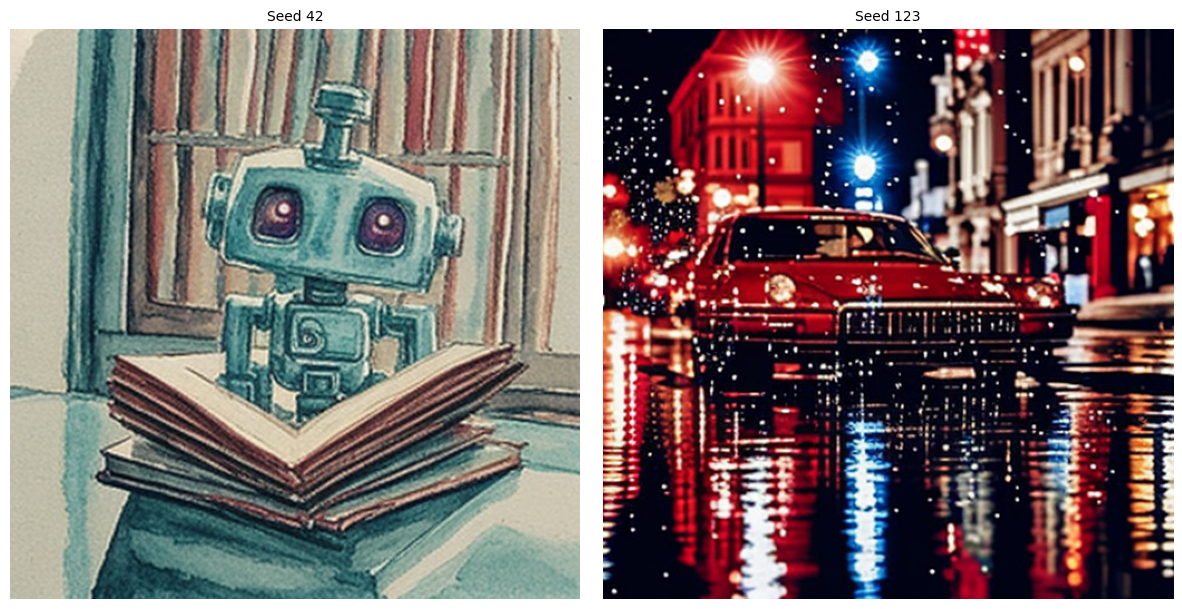

Model: stabilityai/sd-turbo | device: cpu | steps: 4 | guidance_scale: 0.0


In [1]:
# === Day 11 — Diffusion Assignment (Stable Diffusion Turbo) ===
# Works on CPU; uses low steps for speed. If you have CUDA, it will auto-use it.

import os, sys, subprocess, importlib
os.environ["USE_TF"] = "0"  # keep TF out of transformers/diffusers path

def ensure(pkg):
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.invalidate_caches()
        return importlib.import_module(pkg)

# Minimal deps for this cell
torch = ensure("torch")
diffusers = ensure("diffusers")
transformers = ensure("transformers")
safetensors = ensure("safetensors")
PIL = ensure("PIL")
matplotlib = ensure("matplotlib")
certifi = ensure("certifi")

from pathlib import Path
from PIL import Image
from diffusers import AutoPipelineForText2Image
import torch as th
import matplotlib.pyplot as plt

# ---- Choose model (Stable Diffusion Turbo is very fast for demos)
MODEL_ID = "stabilityai/sd-turbo"   # alt (slower, higher quality): "stabilityai/stable-diffusion-2-1"

# ---- Device + dtype
device = "cuda" if th.cuda.is_available() else "cpu"
dtype = th.float16 if device == "cuda" else th.float32

# ---- Load pipeline
pipe = AutoPipelineForText2Image.from_pretrained(MODEL_ID, torch_dtype=dtype)
pipe = pipe.to(device)

# Memory helpers
try:
    pipe.enable_attention_slicing()  # helps on CPU and small GPUs
except Exception:
    pass

# ---- Prompts to try
prompts = [
    "a watercolor painting of a small robot reading a book, soft light, high detail",
    "a cinematic photo of a red vintage sports car parked on a rainy street at night, reflections, bokeh",
    # Add your own prompt ideas:
    # "isometric pixel art of a cozy coffee shop interior, warm colors",
]

# ---- Inference parameters (Turbo: very low steps & guidance_scale=0.0)
num_inference_steps = 4   # Turbo is designed for 1–4 steps
guidance_scale = 0.0      # Turbo uses zero (no CFG) for best speed/quality tradeoff
seeds = [42, 123]         # reproducibility per prompt; extend if you add more prompts

# ---- Output directory
out_dir = Path("assignments/ai_swiss_army_knife_day11/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# ---- Generate
images = []
for i, prompt in enumerate(prompts):
    seed = seeds[i % len(seeds)]
    generator = th.Generator(device=device).manual_seed(seed)
    result = pipe(
        prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
    )
    img = result.images[0]
    images.append((prompt, seed, img))
    fname = out_dir / f"sd_turbo_{i:02d}_seed{seed}.png"
    img.save(fname)
    print(f"Saved: {fname}")

# ---- Display in a simple gallery
cols = 2
rows = (len(images) + cols - 1) // cols
plt.figure(figsize=(12, 6))
for idx, (prompt, seed, img) in enumerate(images, start=1):
    plt.subplot(rows, cols, idx)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Seed {seed}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Model: {MODEL_ID} | device: {device} | steps: {num_inference_steps} | guidance_scale: {guidance_scale}")


## Discussion

- **Model choice.** I used stabilityai/sd-turbo because it’s designed for extremely fast generation with very few steps, which suits CPU execution during this assignment.
- **Prompts & params.** I tested creative and photographic prompts. Turbo works best with num_inference_steps=1–4 and guidance_scale=0.0 (CFG off). I set seeds for reproducibility.
- **Observations.** On CPU, images render quickly (a few seconds per image vs. much longer for standard SD). Turbo tends to produce coherent compositions but with slightly less fine detail than SD 2.1 at higher steps.
- **Challenges.** The main trade-off is quality vs. speed on CPU. If a higher level of detail is needed, a standard SD model can be used with more steps (expect slower runs), or run the same code on a GPU runtime.
- **Findings.** Prompt phrasing matters a lot (style words like “watercolor”, “cinematic”, “bokeh”). Reproducibility via seeds makes side-by-side comparisons easy.